In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv", encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Postal Code'] = df['Postal Code'].fillna(0)
print("Data ready!", df.shape)

Data ready! (9800, 18)


In [2]:
# we will predict:
# Check order HIGH value order or LOW value order?
# If Sales > average sales  = 1 (High)
# If Sales < average sales  = 0 (Low)

average_sales = df['Sales'].mean()
print("Average Sales:", round(average_sales, 2))

df['High_Sales'] = (df['Sales'] > average_sales).astype(int)
print("\nHigh Sales orders:", df['High_Sales'].sum())
print("Low Sales orders:", (df['High_Sales'] == 0).sum())

Average Sales: 230.77

High Sales orders: 2315
Low Sales orders: 7485


In [3]:
# We will convert Category aur Segment to numbers 
# Because ML model only understand numbers 

df['Category_Code'] = df['Category'].astype('category').cat.codes
df['Segment_Code'] = df['Segment'].astype('category').cat.codes
df['Region_Code'] = df['Region'].astype('category').cat.codes

print("Category codes:")
print(df[['Category', 'Category_Code']].drop_duplicates())
print("\nSegment codes:")
print(df[['Segment', 'Segment_Code']].drop_duplicates())

Category codes:
          Category  Category_Code
0        Furniture              0
2  Office Supplies              1
7       Technology              2

Segment codes:
        Segment  Segment_Code
0      Consumer             0
2     Corporate             1
14  Home Office             2


In [6]:
features = ['Category_Code', 'Segment_Code', 'Region_Code']
target = 'High_Sales'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9800, 3)
Target shape: (9800,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train), "rows")
print("Testing data:", len(X_test), "rows")

Training data: 7840 rows
Testing data: 1960 rows


In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy * 100, 2)}%")

Model Accuracy: 76.48%


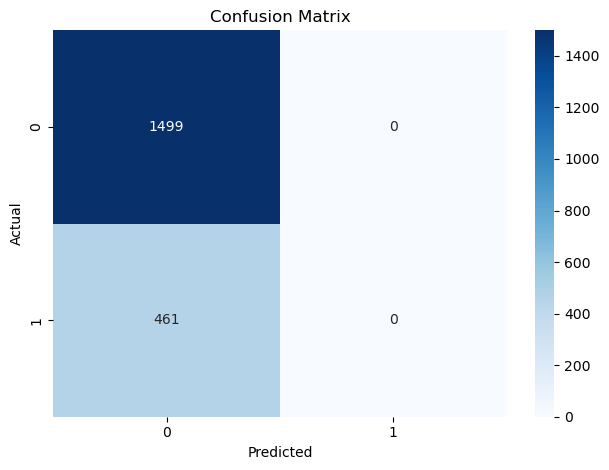

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Model Insights – Week 3

### Problem Statement
Predict whether a sales order is High Value or Low Value
based on Category, Segment, and Region.

### Approach
- Algorithm: Logistic Regression
- Features used: Category, Segment, Region
- Target: High Sales (1) or Low Sales (0)

### Data Split
- Training data: 7840 rows (80%)
- Testing data: 1960 rows (20%)

### Results
- Model Accuracy: 76.48%
- Model correctly identified 1499 out of 1960 Low Sales orders
- Model struggled with High Sales orders due to limited features

### Limitations
- Dataset does not have Profit, Quantity, Discount columns
- More features would improve accuracy further
- 76.48% is a good starting accuracy for a beginner project